In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/geo-referenced-crop-prediction-dataset/CropDataset-Enhanced.csv
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/app.py
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/.env.sample
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/model_trail.ipynb
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/CropDataset-Enhanced.csv
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/models/crop_multilabel_binarizer.pkl
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/models/soil_prediction_models.pkl
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/models/soil_level_encoders.pkl
/kaggle/input/geo-referenced-crop-prediction-dataset/Crop Recommender (1)/Crop Recommender/models/crop_recommender_model.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, hamming_loss, jaccard_score, accuracy_score, confusion_matrix
import joblib
import re
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/geo-referenced-crop-prediction-dataset/CropDataset-Enhanced.csv")

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

First 5 rows of the dataset:


,Address,Status geocode,Formatted address,Latitude,Longitude,Type,Location Type,Country,Region,Crop,...,Phosphorous - High,Phosphorous - Medium,Phosphorous - Low,Potassium - High,Potassium - Medium,Potassium - Low,pH - Acidic,pH - Neutral,pH - Alkaline,
0,Ahilya nagar,Ok,"Ahilya Nagar, Maharashtra, India",19.094829,74.747979,"locality, political",APPROXIMATE,India,Maharashtra,"Sugarcane, Bajra (Pearl Millet), Wheat, Cotton...",...,74.02%,21.09%,4.89%,39.15%,42.81%,18.04%,0.11%,96.02%,3.87%,NaN
1,Akola,Ok,"Akola, Maharashtra, India",20.700216,77.008168,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Soybean, Jowar (Sorghum), Wheat, Tur (...",...,68.52%,28.76%,2.72%,84.11%,14.74%,1.14%,0%,95.62%,4.38%,NaN
2,Amravati,Ok,"Amravati, Maharashtra, India",20.931982,77.752304,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Soybean, Jowar (Sorghum), Wheat, Tur (...",...,9.76%,28.19%,62.05%,80.88%,6.25%,12.87%,13.44%,84.55%,2.01%,NaN
3,"Chhatrapati Sambhaji Nagar, Maharashtra",Ok,"Chhatrapati Sambhaji Nagar, Maharashtra, India",19.875754,75.339320,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Bajra (Pearl Millet), Wheat, Sugarcane...",...,61.51%,30.92%,7.57%,73.23%,24.86%,1.91%,0%,90.48%,9.52%,NaN
4,"Beed, Maharashtra",Ok,"Beed, Maharashtra 431122, India",18.990088,75.753132,"locality, political",APPROXIMATE,India,Maharashtra,"Cotton, Bajra (Pearl Millet), Wheat, Sugarcane...",...,13.78%,75.24%,10.98%,52.74%,42.98%,4.28%,0.11%,90.24%,9.65%,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Address               730 non-null    object 
 1   Status geocode        730 non-null    object 
 2   Formatted address     730 non-null    object 
 3   Latitude              730 non-null    float64
 4   Longitude             730 non-null    float64
 5   Type                  730 non-null    object 
 6   Location Type         730 non-null    object 
 7   Country               730 non-null    object 
 8   Region                730 non-null    object 
 9   Crop                  730 non-null    object 
 10  Nitrogen - High       695 non-null    object 
 11  Nitrogen - Medium     695 non-null    object 
 12  Nitrogen - Low        695 non-null    object 
 13  Phosphorous - High    695 non-null    object 
 14  Phosphorous - Medium  695 non-null    object 
 15  P

,Latitude,Longitude,
count,730.000000,730.000000,0.0
mean,23.132890,81.557166,NaN
std,5.687356,6.582537,NaN
min,7.120539,69.383108,NaN
25%,20.114212,76.662962,NaN
50%,24.352397,79.631580,NaN
75%,26.831373,85.872046,NaN
max,34.553852,96.835100,NaN



Missing values in each column:
Address                   0
Status geocode            0
Formatted address         0
Latitude                  0
Longitude                 0
Type                      0
Location Type             0
Country                   0
Region                    0
Crop                      0
Nitrogen - High          35
Nitrogen - Medium        35
Nitrogen - Low           35
Phosphorous - High       35
Phosphorous - Medium     35
Phosphorous - Low        35
Potassium - High         35
Potassium - Medium       35
Potassium - Low          35
pH - Acidic              35
pH - Neutral             35
pH - Alkaline            35
                        730
dtype: int64


Number of unique crops: 584

Sample of crops available in the dataset:
['Paddy, Wheat, Mustard'
 'Cotton, Soybean, Jowar (Sorghum), Wheat, Tur (Pigeon Pea), Oranges'
 'Cotton, Groundnut, Jowar, Paddy' 'Wheat, gram, and paddy'
 'Paddy, Groundnut, Pulses' 'Wheat, Bajra, Castor'
 'Sugarcane, Paddy, Wheat, Mustard' 'Maize, Wheat, Mustard, Pulses'
 'Paddy, Wheat, Maize' 'Sugarcane, Paddy, Cotton']


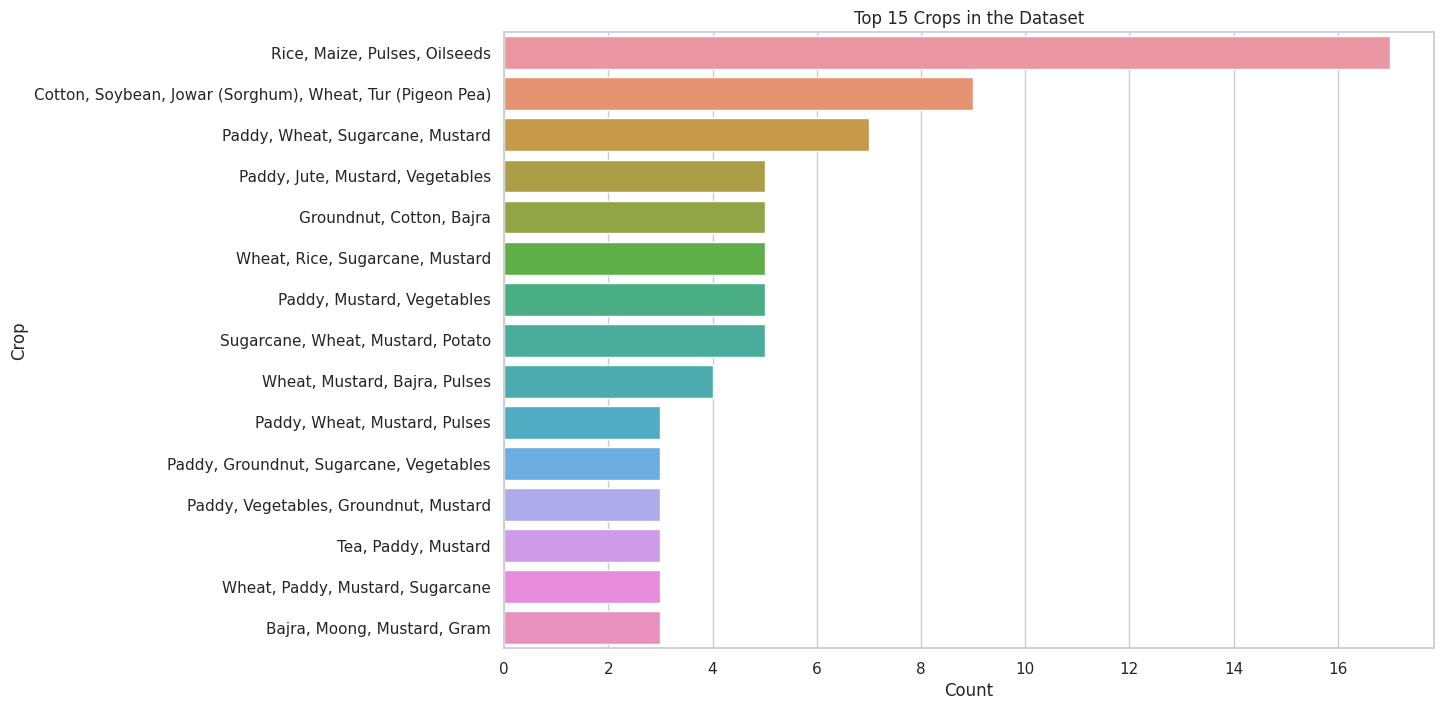

Data types of nutrient columns:
Nitrogen - High         object
Nitrogen - Medium       object
Nitrogen - Low          object
Phosphorous - High      object
Phosphorous - Medium    object
Phosphorous - Low       object
Potassium - High        object
Potassium - Medium      object
Potassium - Low         object
pH - Acidic             object
pH - Neutral            object
pH - Alkaline           object
dtype: object


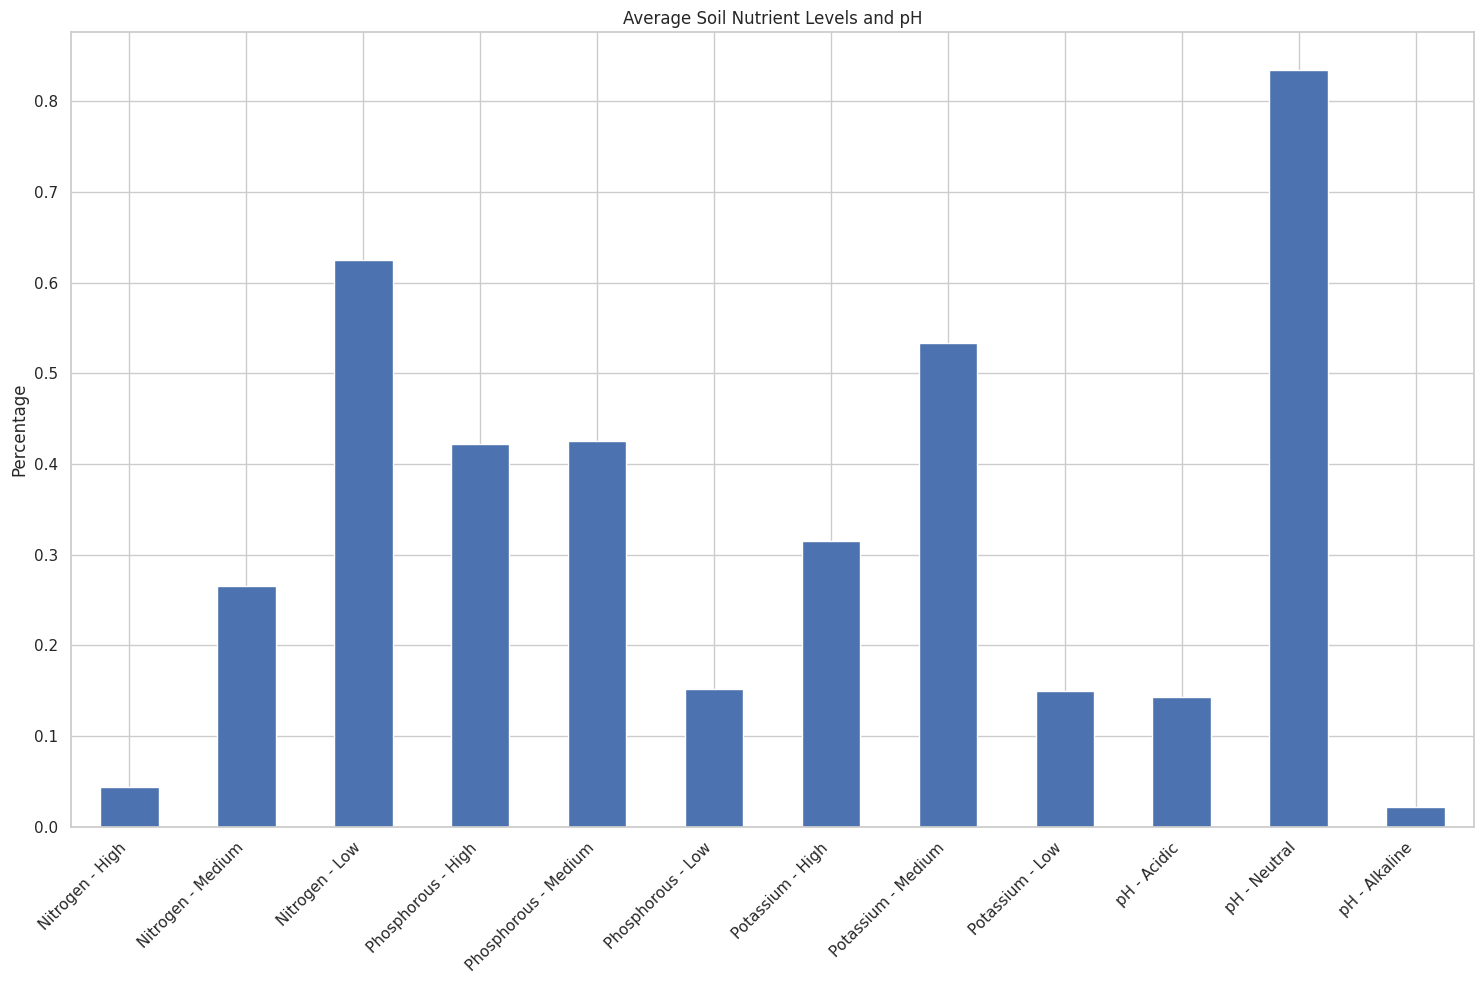

In [4]:
# Check unique values in the Crop column
print("Number of unique crops:", df['Crop'].nunique())
print("\nSample of crops available in the dataset:")
print(df['Crop'].sample(10).values)

# Create a visualization of regions and their top crops
plt.figure(figsize=(12, 8))
crop_counts = df['Crop'].value_counts().head(15)
sns.barplot(x=crop_counts.values, y=crop_counts.index)
plt.title('Top 15 Crops in the Dataset')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.show()

# Distribution of soil nutrient levels across regions
nutrient_columns = [col for col in df.columns if any(x in col for x in ['Nitrogen', 'Phosphorous', 'Potassium', 'pH'])]

# First, check the data types of your nutrient columns
print("Data types of nutrient columns:")
print(df[nutrient_columns].dtypes)

# Convert percentage strings to numerical values before calculating mean
for col in nutrient_columns:
    # Strip the '%' symbol and convert to float
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) / 100

# Now calculate the mean and plot
plt.figure(figsize=(15, 10))
df[nutrient_columns].mean().plot(kind='bar')
plt.title('Average Soil Nutrient Levels and pH')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Clean the dataset
# Drop unnecessary columns
df_clean = df.drop(columns=["Status geocode", "Formatted address", "Type", "Location Type", 
                            "Country", "Address", "Unnamed: 22"], errors='ignore')

# Convert percentage strings to float values
percentage_cols = [col for col in df_clean.columns if any(x in col for x in ['Nitrogen', 'Phosphorous', 'Potassium', 'pH'])]

for col in percentage_cols:
    # Convert percentage strings to float values
    df_clean[col] = df_clean[col].astype(str).str.replace('%', '').astype(float) / 100

# Clean and process the Crop column for multi-label classification
df_clean['crops_list'] = df_clean['Crop'].fillna('').apply(
    lambda x: [crop.strip() for crop in re.split(r'[,;]', x) if crop.strip()]
)

# Display the cleaned dataset
print("Cleaned dataset sample:")
display(df_clean[['Region', 'Latitude', 'Longitude', 'crops_list'] + percentage_cols].head())

print("\nFeatures shape after cleaning:", df_clean.shape)

Cleaned dataset sample:


,Region,Latitude,Longitude,crops_list,Nitrogen - High,Nitrogen - Medium,Nitrogen - Low,Phosphorous - High,Phosphorous - Medium,Phosphorous - Low,Potassium - High,Potassium - Medium,Potassium - Low,pH - Acidic,pH - Neutral,pH - Alkaline
0,Maharashtra,19.094829,74.747979,"[Sugarcane, Bajra (Pearl Millet), Wheat, Cotto...",0.000003,0.000355,0.009642,0.007402,0.002109,0.000489,0.003915,0.004281,0.001804,0.000011,0.009602,0.000387
1,Maharashtra,20.700216,77.008168,"[Cotton, Soybean, Jowar (Sorghum), Wheat, Tur ...",0.000005,0.000028,0.009967,0.006852,0.002876,0.000272,0.008411,0.001474,0.000114,0.000000,0.009562,0.000438
2,Maharashtra,20.931982,77.752304,"[Cotton, Soybean, Jowar (Sorghum), Wheat, Tur ...",0.000010,0.000087,0.009903,0.000976,0.002819,0.006205,0.008088,0.000625,0.001287,0.001344,0.008455,0.000201
3,Maharashtra,19.875754,75.339320,"[Cotton, Bajra (Pearl Millet), Wheat, Sugarcan...",0.000003,0.000191,0.009807,0.006151,0.003092,0.000757,0.007323,0.002486,0.000191,0.000000,0.009048,0.000952
4,Maharashtra,18.990088,75.753132,"[Cotton, Bajra (Pearl Millet), Wheat, Sugarcan...",0.000219,0.003657,0.006125,0.001378,0.007524,0.001098,0.005274,0.004298,0.000428,0.000011,0.009024,0.000965



Features shape after cleaning: (730, 18)


Sample of extracted dominant soil characteristic levels:


,Region,N_level,P_level,K_level,pH_level,crops_list
0,Maharashtra,Low,High,Medium,Neutral,"[Sugarcane, Bajra (Pearl Millet), Wheat, Cotto..."
1,Maharashtra,Low,High,High,Neutral,"[Cotton, Soybean, Jowar (Sorghum), Wheat, Tur ..."
2,Maharashtra,Low,Low,High,Neutral,"[Cotton, Soybean, Jowar (Sorghum), Wheat, Tur ..."
3,Maharashtra,Low,High,High,Neutral,"[Cotton, Bajra (Pearl Millet), Wheat, Sugarcan..."
4,Maharashtra,Low,Medium,High,Neutral,"[Cotton, Bajra (Pearl Millet), Wheat, Sugarcan..."
5,Maharashtra,Low,Low,High,Neutral,"[Rice, Wheat, Linseed, Tur (Pigeon Pea), Mustard]"
6,Maharashtra,Low,Medium,High,Neutral,"[Cotton, Soybean, Jowar (Sorghum), Wheat, Tur ..."
7,Maharashtra,Low,Medium,Medium,Neutral,"[Rice, Cotton, Soybean, Jowar (Sorghum), Tur (..."
8,Maharashtra,Low,Medium,High,Neutral,"[Cotton, Bajra (Pearl Millet), Wheat, Groundnu..."
9,Maharashtra,Low,Medium,Medium,Neutral,"[Rice, Linseed, Mustard, Tur (Pigeon Pea)]"



Distribution of dominant soil levels:

N_level distribution:
N_level
Low       457
Medium    171
High       67
Name: count, dtype: int64

P_level distribution:
P_level
High      325
Medium    308
Low        62
Name: count, dtype: int64

K_level distribution:
K_level
Medium    422
High      207
Low        66
Name: count, dtype: int64

pH_level distribution:
pH_level
Neutral     605
Acidic       88
Alkaline      2
Name: count, dtype: int64


<Figure size 1500x1000 with 0 Axes>

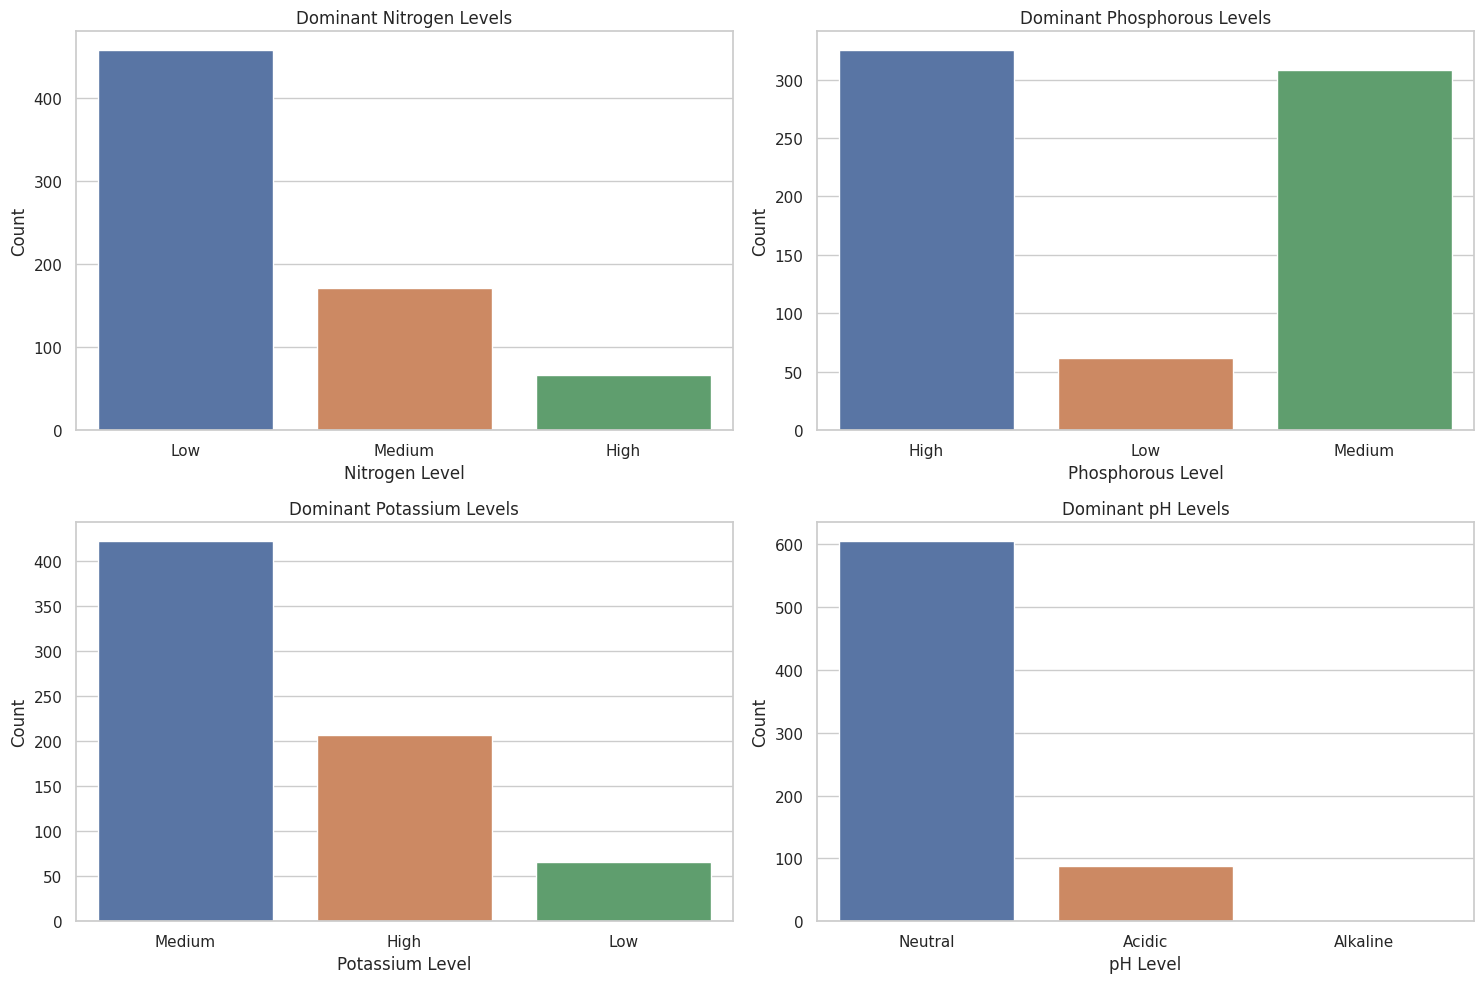

In [6]:
# Extract dominant level for each soil characteristic
# For Nitrogen
df_clean['N_level'] = df_clean[['Nitrogen - High', 'Nitrogen - Medium', 'Nitrogen - Low']].idxmax(axis=1).str.split(' - ').str[1]

# For Phosphorous
df_clean['P_level'] = df_clean[['Phosphorous - High', 'Phosphorous - Medium', 'Phosphorous - Low']].idxmax(axis=1).str.split(' - ').str[1]

# For Potassium
df_clean['K_level'] = df_clean[['Potassium - High', 'Potassium - Medium', 'Potassium - Low']].idxmax(axis=1).str.split(' - ').str[1]

# For pH
df_clean['pH_level'] = df_clean[['pH - Acidic', 'pH - Neutral', 'pH - Alkaline']].idxmax(axis=1).str.split(' - ').str[1]

# Display the extracted dominant levels
print("Sample of extracted dominant soil characteristic levels:")
display(df_clean[['Region', 'N_level', 'P_level', 'K_level', 'pH_level', 'crops_list']].head(10))

# Count distribution of each level
print("\nDistribution of dominant soil levels:")
for col in ['N_level', 'P_level', 'K_level', 'pH_level']:
    print(f"\n{col} distribution:")
    print(df_clean[col].value_counts())
    
# Visualize the distribution of dominant soil characteristics
plt.figure(figsize=(15, 10))
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(x='N_level', data=df_clean, ax=axs[0, 0])
axs[0, 0].set_title('Dominant Nitrogen Levels')
axs[0, 0].set_xlabel('Nitrogen Level')
axs[0, 0].set_ylabel('Count')

sns.countplot(x='P_level', data=df_clean, ax=axs[0, 1])
axs[0, 1].set_title('Dominant Phosphorous Levels')
axs[0, 1].set_xlabel('Phosphorous Level')
axs[0, 1].set_ylabel('Count')

sns.countplot(x='K_level', data=df_clean, ax=axs[1, 0])
axs[1, 0].set_title('Dominant Potassium Levels')
axs[1, 0].set_xlabel('Potassium Level')
axs[1, 0].set_ylabel('Count')

sns.countplot(x='pH_level', data=df_clean, ax=axs[1, 1])
axs[1, 1].set_title('Dominant pH Levels')
axs[1, 1].set_xlabel('pH Level')
axs[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
# Create a new feature set using the categorical soil levels
# One-hot encode the categorical features
cat_features = pd.get_dummies(df_clean[['N_level', 'P_level', 'K_level', 'pH_level']], prefix=['N', 'P', 'K', 'pH'])

# Add location data
X_categorical = pd.concat([df_clean[['Latitude', 'Longitude']], cat_features], axis=1)

# Display the categorical feature set
print("Categorical feature set shape:", X_categorical.shape)
print("Sample of categorical features:")
display(X_categorical.head())

# Scale the numerical features (latitude and longitude)
num_cols = ['Latitude', 'Longitude']
scaler_cat = StandardScaler()
X_categorical[num_cols] = scaler_cat.fit_transform(X_categorical[num_cols])

# Define the target variable (y) using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_clean['crops_list'])

# Train a first-stage classifier using the categorical features
X_cat_train, X_cat_test, y_train_cat, y_test_cat = train_test_split(
    X_categorical, y, test_size=0.2, random_state=42
)

print("Training categorical feature model...")
cat_base_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

cat_model = MultiOutputClassifier(cat_base_model)
cat_model.fit(X_cat_train, y_train_cat)

# Evaluate the categorical feature model
y_cat_pred = cat_model.predict(X_cat_test)
print("\nCategorical Feature Model Evaluation:")
print(f"Hamming Loss: {hamming_loss(y_test_cat, y_cat_pred):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test_cat, y_cat_pred, average='samples'):.4f}")

Categorical feature set shape: (730, 14)
Sample of categorical features:


,Latitude,Longitude,N_High,N_Low,N_Medium,P_High,P_Low,P_Medium,K_High,K_Low,K_Medium,pH_Acidic,pH_Alkaline,pH_Neutral
0,19.094829,74.747979,False,True,False,True,False,False,False,False,True,False,False,True
1,20.700216,77.008168,False,True,False,True,False,False,True,False,False,False,False,True
2,20.931982,77.752304,False,True,False,False,True,False,True,False,False,False,False,True
3,19.875754,75.339320,False,True,False,True,False,False,True,False,False,False,False,True
4,18.990088,75.753132,False,True,False,False,False,True,True,False,False,False,False,True


Training categorical feature model...

Categorical Feature Model Evaluation:
Hamming Loss: 0.0157
Jaccard Score: 0.3565



Creating Soil Predictor Model based on location
N_level encoding mapping: {'High': 0, 'Low': 1, 'Medium': 2, nan: 3}
P_level encoding mapping: {'High': 0, 'Low': 1, 'Medium': 2, nan: 3}
K_level encoding mapping: {'High': 0, 'Low': 1, 'Medium': 2, nan: 3}
pH_level encoding mapping: {'Acidic': 0, 'Alkaline': 1, 'Neutral': 2, nan: 3}

Training N_level prediction model...
N_level prediction accuracy: 0.7603

Classification report:
              precision    recall  f1-score   support

        High       0.80      0.57      0.67        14
         Low       0.79      0.89      0.83        88
      Medium       0.70      0.53      0.60        40
         nan       0.57      1.00      0.73         4

    accuracy                           0.76       146
   macro avg       0.71      0.75      0.71       146
weighted avg       0.76      0.76      0.75       146



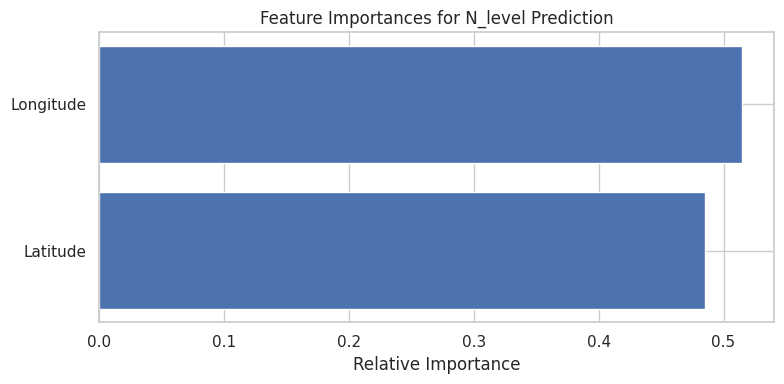


Training P_level prediction model...
P_level prediction accuracy: 0.6301

Classification report:
              precision    recall  f1-score   support

        High       0.64      0.70      0.67        64
         Low       0.29      0.15      0.20        13
      Medium       0.65      0.63      0.64        65
         nan       0.67      1.00      0.80         4

    accuracy                           0.63       146
   macro avg       0.56      0.62      0.58       146
weighted avg       0.62      0.63      0.62       146



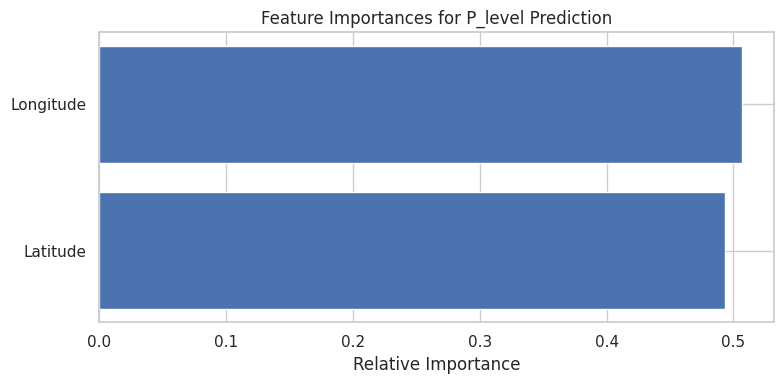


Training K_level prediction model...
K_level prediction accuracy: 0.6644

Classification report:
              precision    recall  f1-score   support

        High       0.53      0.57      0.55        37
         Low       0.67      0.32      0.43        19
      Medium       0.73      0.77      0.75        86
         nan       0.57      1.00      0.73         4

    accuracy                           0.66       146
   macro avg       0.62      0.66      0.61       146
weighted avg       0.67      0.66      0.66       146



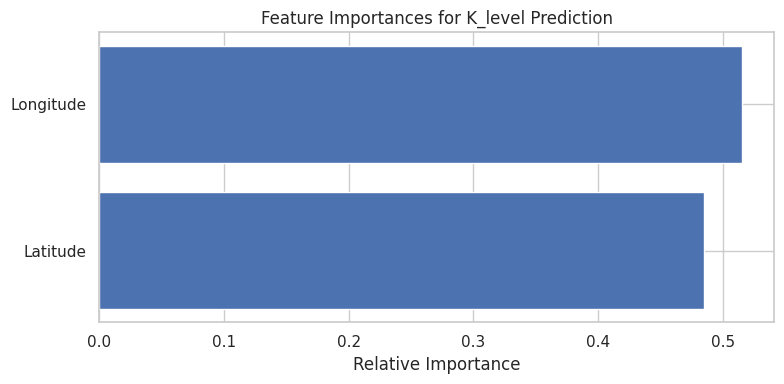


Training pH_level prediction model...
pH_level prediction accuracy: 0.8630

Classification report:
              precision    recall  f1-score   support

      Acidic       0.65      0.50      0.56        22
    Alkaline       0.00      0.00      0.00         1
     Neutral       0.90      0.93      0.92       119
         nan       0.67      1.00      0.80         4

    accuracy                           0.86       146
   macro avg       0.55      0.61      0.57       146
weighted avg       0.85      0.86      0.85       146



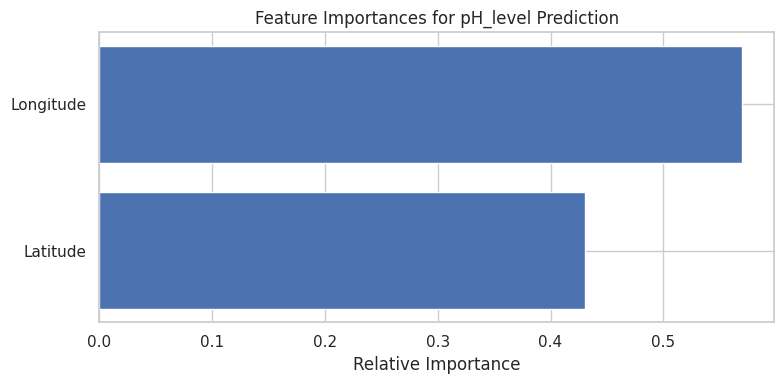

In [8]:

print("\n" + "="*80)
print("Creating Soil Predictor Model based on location")
print("="*80)

# Prepare data for soil predictor model
# Features: location (latitude, longitude)
X_soil = df_clean[['Latitude', 'Longitude']]

# Targets: soil characteristic levels 
# We'll use LabelEncoder to convert categorical levels to numbers
soil_levels = ['N_level', 'P_level', 'K_level', 'pH_level']
soil_encoders = {}
y_soil_encoded = pd.DataFrame()

# Encode each soil characteristic
for level in soil_levels:
    encoder = LabelEncoder()
    y_soil_encoded[level] = encoder.fit_transform(df_clean[level])
    soil_encoders[level] = encoder
    print(f"{level} encoding mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Scale features
soil_scaler = StandardScaler()
X_soil_scaled = soil_scaler.fit_transform(X_soil)

# Split data for soil prediction model
X_soil_train, X_soil_test, y_soil_train, y_soil_test = train_test_split(
    X_soil_scaled, y_soil_encoded, test_size=0.2, random_state=42
)

# Train soil prediction models (one for each characteristic)
soil_models = {}
soil_accuracy = {}

for level in soil_levels:
    print(f"\nTraining {level} prediction model...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_soil_train, y_soil_train[level])
    soil_models[level] = model
    
    # Evaluate model
    y_pred = model.predict(X_soil_test)
    accuracy = accuracy_score(y_soil_test[level], y_pred)
    soil_accuracy[level] = accuracy
    
    print(f"{level} prediction accuracy: {accuracy:.4f}")
    
    # Display classification report
    print("\nClassification report:")
    target_names = [str(name) for name in soil_encoders[level].classes_]
    print(classification_report(y_soil_test[level], y_pred, target_names=target_names))
    
    # Plot feature importances
    if hasattr(model, 'feature_importances_'):
        plt.figure(figsize=(8, 4))
        importances = model.feature_importances_
        indices = np.argsort(importances)
        features = ['Latitude', 'Longitude']
        plt.title(f'Feature Importances for {level} Prediction')
        plt.barh(range(len(indices)), importances[indices], align='center')
        plt.yticks(range(len(indices)), [features[i] for i in indices])
        plt.xlabel('Relative Importance')
        plt.tight_layout()
        plt.show()


In [9]:

# Save soil prediction models and components
joblib.dump(soil_models, 'soil_prediction_models.pkl')
joblib.dump(soil_encoders, 'soil_level_encoders.pkl')
joblib.dump(soil_scaler, 'soil_feature_scaler.pkl')

# Create a function to predict soil characteristics from location
def predict_soil_characteristics(latitude, longitude):
    """
    Predict soil characteristics (N, P, K, pH levels) based on location
    
    Parameters:
    -----------
    latitude : float
        Latitude coordinate
    longitude : float
        Longitude coordinate
        
    Returns:
    --------
    dict
        Dictionary with predicted soil characteristics
    """
    # Prepare input data
    input_location = np.array([[latitude, longitude]])
    
    # Scale the input
    input_scaled = soil_scaler.transform(input_location)
    
    # Make predictions for each soil characteristic
    predictions = {}
    
    for level in soil_levels:
        # Predict encoded level
        level_encoded = soil_models[level].predict(input_scaled)[0]
        
        # Decode to get the actual level name
        level_name = soil_encoders[level].inverse_transform([level_encoded])[0]
        
        # Store in predictions dictionary
        predictions[level] = level_name
    
    return predictions




Soil characteristic predictions for sample locations:

Location (28.6139, 77.209):
- N_level: nan
- P_level: nan
- K_level: nan
- pH_level: nan

Location (19.076, 72.8777):
- N_level: nan
- P_level: nan
- K_level: nan
- pH_level: nan

Location (22.5726, 88.3639):
- N_level: Medium
- P_level: High
- K_level: High
- pH_level: Neutral


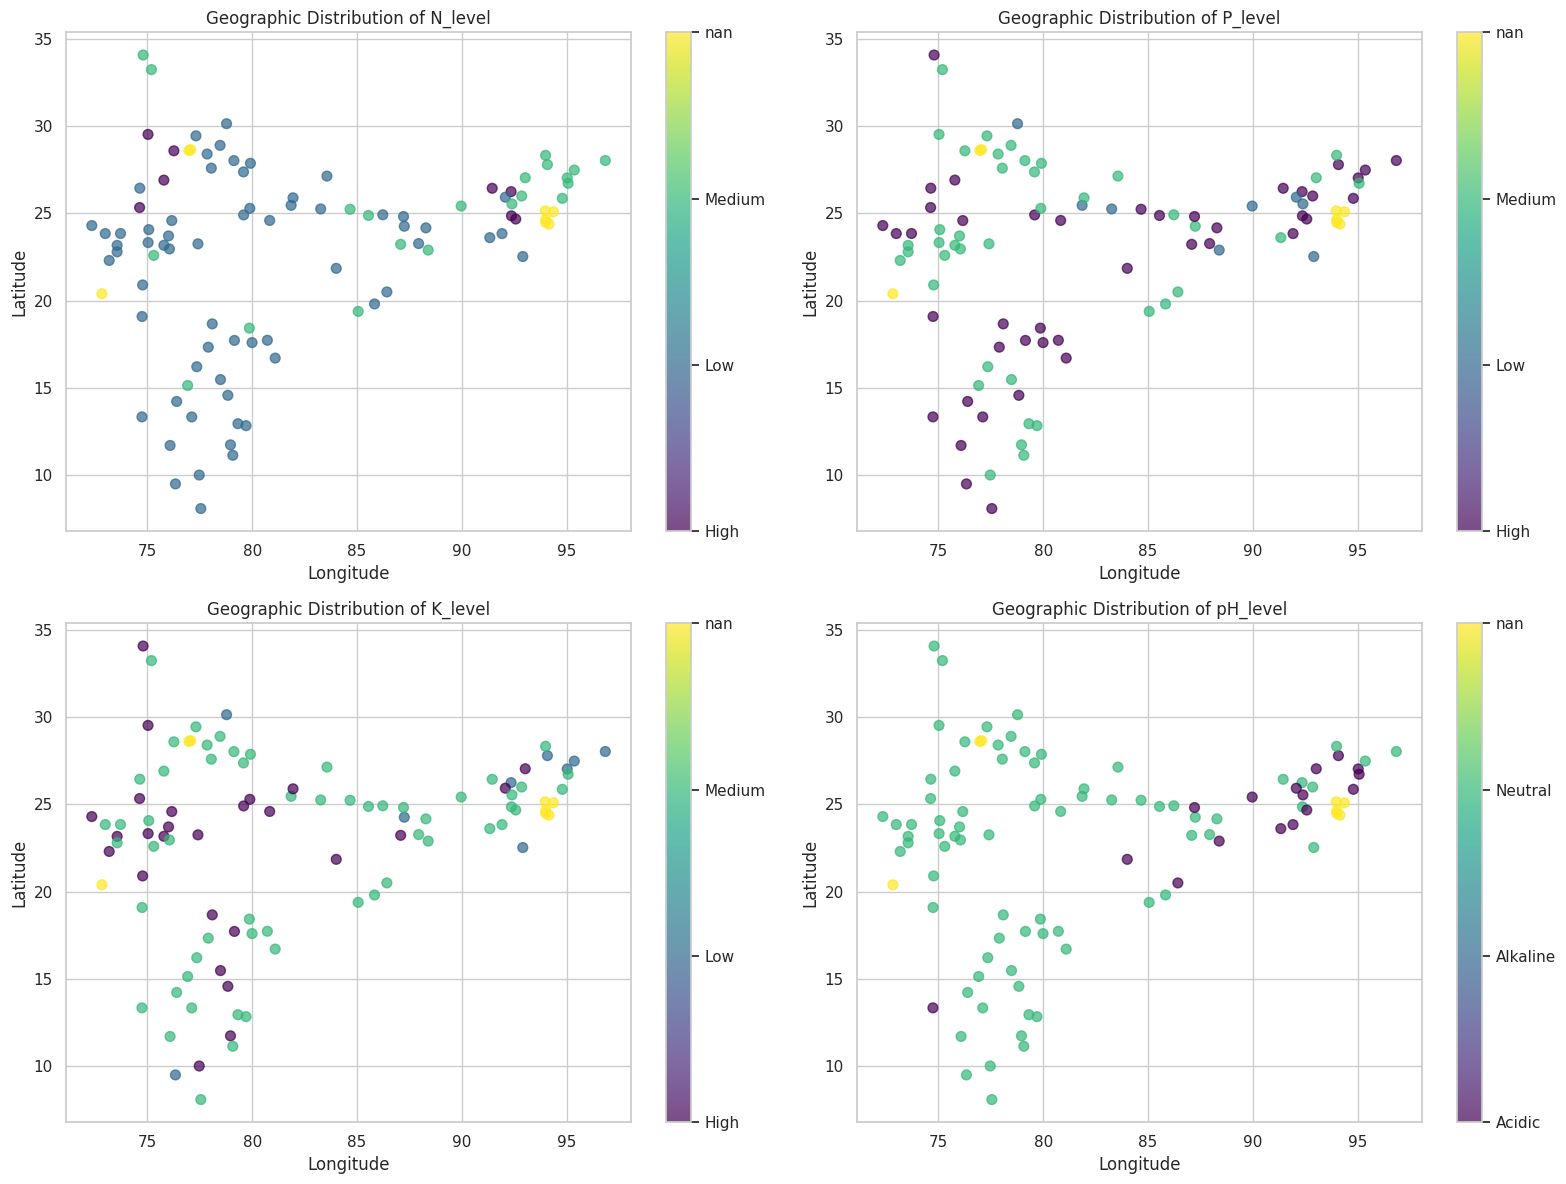


Soil prediction model training complete!
You can now use the 'predict_soil_characteristics' function to predict soil characteristics for any location.


In [10]:

# Test the soil prediction function with sample locations
test_locations = [
    (28.6139, 77.2090),  # New Delhi
    (19.0760, 72.8777),  # Mumbai
    (22.5726, 88.3639)   # Kolkata
]

print("\nSoil characteristic predictions for sample locations:")
for lat, lon in test_locations:
    predictions = predict_soil_characteristics(lat, lon)
    print(f"\nLocation ({lat}, {lon}):")
    for level, value in predictions.items():
        print(f"- {level}: {value}")

# Create a visualization showing the relationship between location and soil characteristics
# Sample 100 random locations from the dataset for visualization
sample_size = min(100, len(df_clean))
sample_indices = np.random.choice(len(df_clean), sample_size, replace=False)
sample_data = df_clean.iloc[sample_indices]

# Create scatter plots colored by each soil characteristic
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for i, level in enumerate(soil_levels):
    scatter = axs[i].scatter(
        sample_data['Longitude'], 
        sample_data['Latitude'],
        c=soil_encoders[level].transform(sample_data[level]),
        cmap='viridis',
        alpha=0.7,
        s=50
    )
    
    axs[i].set_title(f'Geographic Distribution of {level}')
    axs[i].set_xlabel('Longitude')
    axs[i].set_ylabel('Latitude')
    
    # Add colorbar with level labels
    cbar = plt.colorbar(scatter, ax=axs[i])
    cbar.set_ticks(range(len(soil_encoders[level].classes_)))
    cbar.set_ticklabels(soil_encoders[level].classes_)

plt.tight_layout()
plt.show()

print("\nSoil prediction model training complete!")
print("You can now use the 'predict_soil_characteristics' function to predict soil characteristics for any location.")
